In [ ]:
# Task 2: House Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
# Step 3: Dataset Information

print("Dataset Information:")
df.info()

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   

In [5]:
# Step 4: Statistical Summary

print("Statistical Summary:")

df.describe()

Statistical Summary:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
# Step 5: Check Duplicate Records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [7]:
# Step 6: Analyze Target Variable

print("Target Variable: price")
print("\nPrice Statistics:")
print(df["price"].describe())

print("\nNumber of Zero Prices:")
print((df["price"] == 0).sum())

Target Variable: price

Price Statistics:
count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

Number of Zero Prices:
49


In [8]:
# Step 7: Inspect Zero Price Records

zero_price_rows = df[df["price"] == 0]

print("Number of zero-price records:", len(zero_price_rows))

zero_price_rows.head()

Number of zero-price records: 49


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4354,2014-05-05 00:00:00,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,USA
4356,2014-05-05 00:00:00,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,USA
4357,2014-05-05 00:00:00,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,USA
4358,2014-05-06 00:00:00,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,USA
4361,2014-05-07 00:00:00,0.0,5.0,1.50,1500,7112,1.0,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,USA


In [9]:
# Step 8: Remove records with zero price

df = df[df["price"] > 0].copy()

print("Dataset shape after removing zero-price records:")
print(df.shape)

print("\nRemaining zero-price records:")
print((df["price"] == 0).sum())

Dataset shape after removing zero-price records:
(4551, 18)

Remaining zero-price records:
0


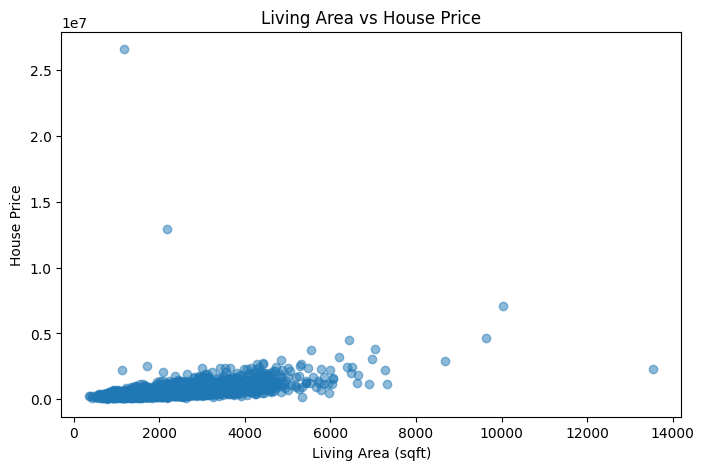

In [10]:
# Step 9: Scatter Plot
# Relationship between Living Area and House Price

plt.figure(figsize=(8, 5))

plt.scatter(df["sqft_living"], df["price"], alpha=0.5)

plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")
plt.title("Living Area vs House Price")

plt.show()

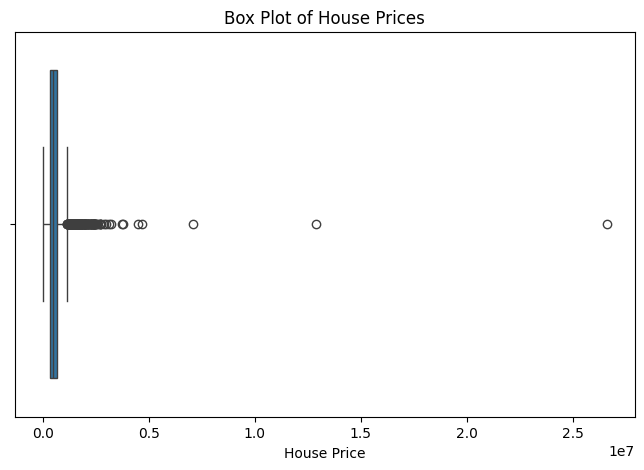

In [11]:
# Step 10: Box Plot
# Check price distribution and possible outliers

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price"])

plt.xlabel("House Price")
plt.title("Box Plot of House Prices")

plt.show()

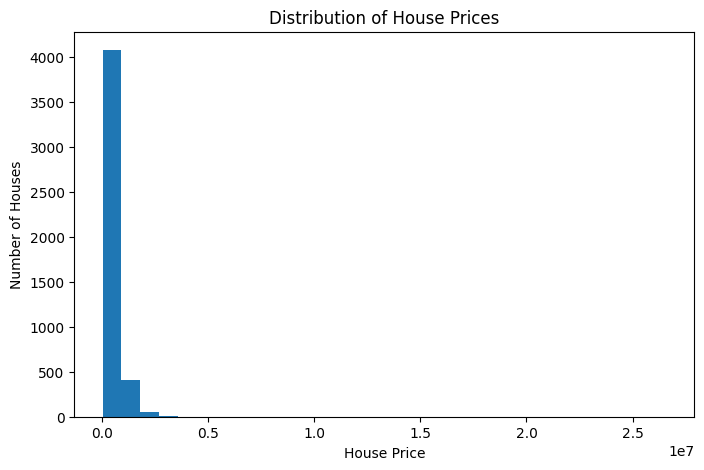

In [12]:
# Step 11: Histogram
# Distribution of House Prices

plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=30)

plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()

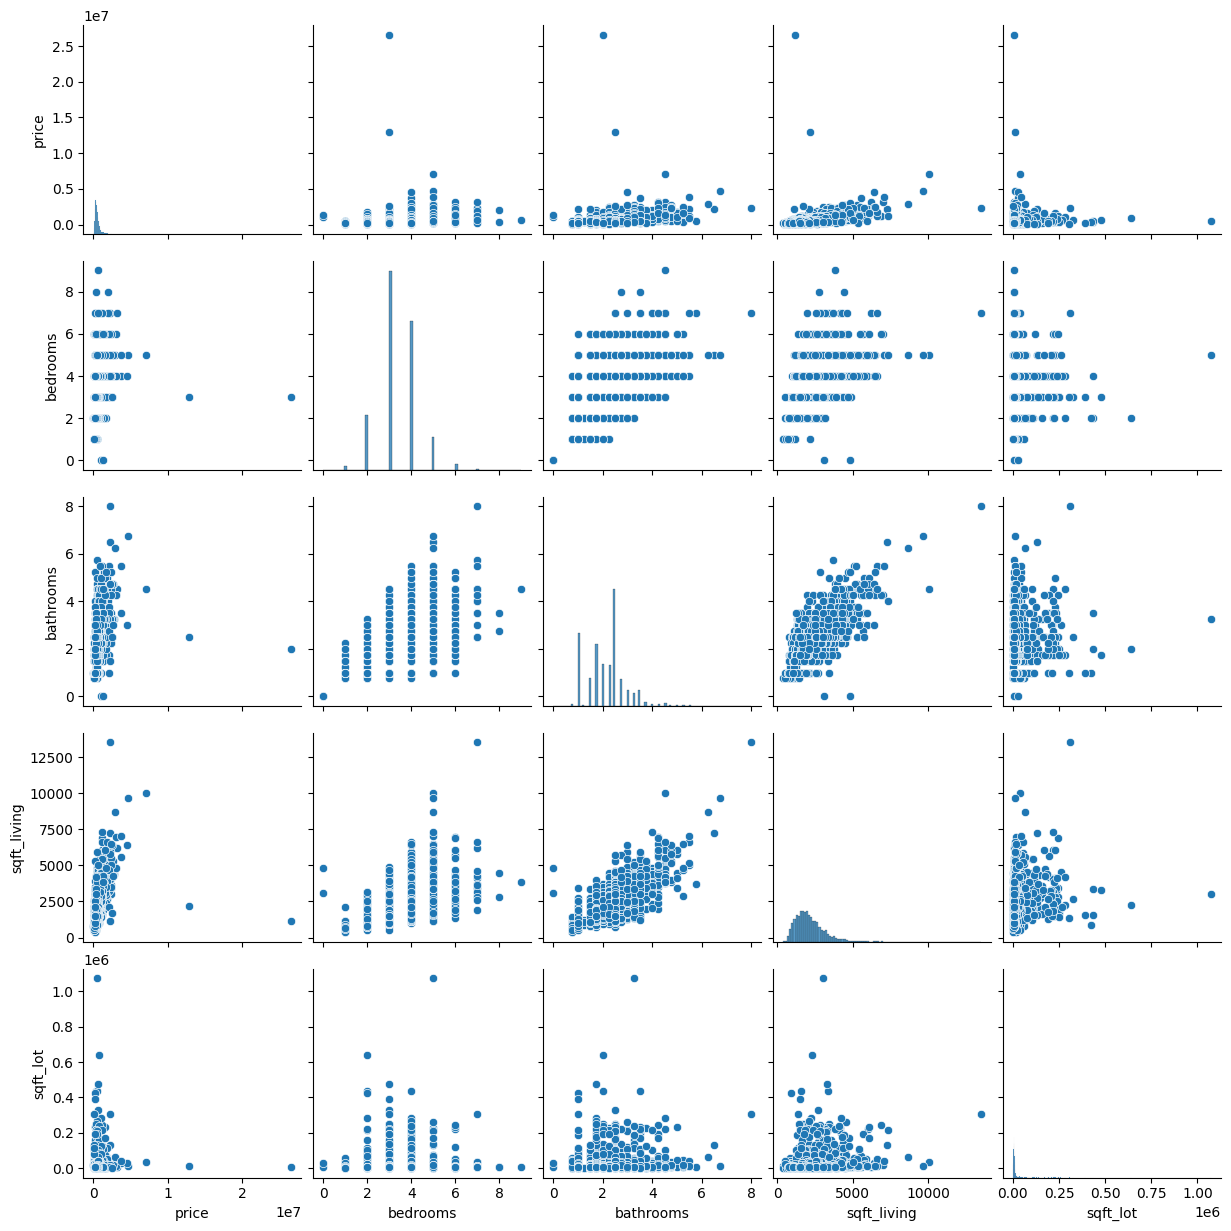

In [13]:
# Step 12: Pair Plot
# Relationship between important numerical features

selected_features = [
    "price",
        "bedrooms",
            "bathrooms",
                "sqft_living",
                    "sqft_lot"
                    ]

sns.pairplot(df[selected_features])
plt.show()

In [14]:
# Step 13: Identify Numerical and Categorical Features

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

Categorical Features:
['date', 'street', 'city', 'statezip', 'country']


In [15]:
# Step 14: Date Feature Engineering

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract useful date features
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

print("Date feature engineering completed!")

print("\nNew columns:")
print(df[["date", "sale_year", "sale_month"]].head())

Date feature engineering completed!

New columns:
        date  sale_year  sale_month
0 2014-05-02       2014           5
1 2014-05-02       2014           5
2 2014-05-02       2014           5
3 2014-05-02       2014           5
4 2014-05-02       2014           5


In [16]:
# Step 15: Remove Original Date Column

df = df.drop(columns=["date"])

print("Original date column removed successfully!")

print("\nCurrent columns:")
print(df.columns.tolist())

Original date column removed successfully!

Current columns:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country', 'sale_year', 'sale_month']


In [17]:
# Step 16: Feature Engineering

# Total usable square footage
df["total_sqft"] = df["sqft_living"] + df["sqft_basement"]

# Age of the house at the time of sale
df["house_age"] = df["sale_year"] - df["yr_built"]

print("New features created successfully!")

print("\nNew Features:")
print(df[["sqft_living", "sqft_basement", "total_sqft",
          "yr_built", "sale_year", "house_age"]].head())

New features created successfully!

New Features:
   sqft_living  sqft_basement  total_sqft  yr_built  sale_year  house_age
0         1340              0        1340      1955       2014         59
1         3650            280        3930      1921       2014         93
2         1930              0        1930      1966       2014         48
3         2000           1000        3000      1963       2014         51
4         1940            800        2740      1976       2014         38


In [18]:
# Step 17: Check Missing Values After Feature Engineering

print("Missing Values After Feature Engineering:")
print(df.isnull().sum())

Missing Values After Feature Engineering:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
sale_year        0
sale_month       0
total_sqft       0
house_age        0
dtype: int64


In [21]:
# Step 18: Check Categorical Features

categorical_features = ["street", "city", "statezip", "country"]

for column in categorical_features:
        print(f"\n{column}:")
        print("Unique values:",
df[column].nunique())
        print("Sample values:")
        print(df[column].unique()[:10])


street:
Unique values: 4476
Sample values:
['18810 Densmore Ave N' '709 W Blaine St' '26206-26214 143rd Ave SE'
 '857 170th Pl NE' '9105 170th Ave NE' '522 NE 88th St'
 '2616 174th Ave NE' '23762 SE 253rd Pl' '46611-46625 SE 129th St'
 '6811 55th Ave NE']

city:
Unique values: 44
Sample values:
['Shoreline' 'Seattle' 'Kent' 'Bellevue' 'Redmond' 'Maple Valley'
 'North Bend' 'Lake Forest Park' 'Sammamish' 'Auburn']

statezip:
Unique values: 77
Sample values:
['WA 98133' 'WA 98119' 'WA 98042' 'WA 98008' 'WA 98052' 'WA 98115'
 'WA 98038' 'WA 98045' 'WA 98155' 'WA 98105']

country:
Unique values: 1
Sample values:
['USA']


In [22]:
# Step 19: Remove High-Cardinality and Constant Columns

df = df.drop(columns=["street", "country"])

print("Removed columns: street, country")

print("\nRemaining categorical columns:")
print(df.select_dtypes(include=["object"]).columns.tolist())

Removed columns: street, country

Remaining categorical columns:
['city', 'statezip']


In [24]:
# Step 20: One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
        columns=["city", "statezip"],
            drop_first=True
            )

print("One-Hot Encoding completed!")

print("\nNew Dataset Shape:")
print(df_encoded.shape)

print("\nFirst 5 rows:")
df_encoded.head()

One-Hot Encoding completed!

New Dataset Shape:
(4551, 136)

First 5 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,False
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,False
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,False


In [25]:
# Step 21: Log Transformation

df_encoded["log_price"] = np.log1p(df_encoded["price"])
df_encoded["log_sqft_living"] = np.log1p(df_encoded["sqft_living"])
df_encoded["log_sqft_lot"] = np.log1p(df_encoded["sqft_lot"])

print("Log transformation completed!")

print("\nTransformed columns:")
print(df_encoded[[
    "price",
        "log_price",
            "sqft_living",
                "log_sqft_living",
                    "sqft_lot",
                        "log_sqft_lot"
                        ]].head())

Log transformation completed!

Transformed columns:
       price  log_price  sqft_living  log_sqft_living  sqft_lot  log_sqft_lot
0   313000.0  12.653962         1340         7.201171      7912      8.976262
1  2384000.0  14.684291         3650         8.202756      9050      9.110631
2   342000.0  12.742569         1930         7.565793     11947      9.388319
3   420000.0  12.948012         2000         7.601402      8030      8.991064
4   550000.0  13.217675         1940         7.570959     10500      9.259226


In [26]:
# Step 22: Separate Features (X) and Target (y)

X = df_encoded.drop(columns=["price", "log_price"])
y = df_encoded["log_price"]

print("Features (X) shape:")
print(X.shape)

print("\nTarget (y) shape:")
print(y.shape)

print("\nTarget: log_price")

Features (X) shape:
(4551, 137)

Target (y) shape:
(4551,)

Target: log_price


In [27]:
# Step 23: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
  )

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (3640, 137)
Testing Features: (911, 137)
Training Target: (3640,)
Testing Target: (911,)


In [28]:
# Step 24: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

print("\nScaled Training Shape:")
print(X_train_scaled.shape)

print("\nScaled Testing Shape:")
print(X_test_scaled.shape)

Feature scaling completed!

Scaled Training Shape:
(3640, 137)

Scaled Testing Shape:
(911, 137)


In [29]:
# Step 25: Train Linear Regression Model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [30]:
# Step 26: Linear Regression Prediction and Evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions
y_pred_linear = linear_model.predict(X_test_scaled)

# Calculate RMSE
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

# Calculate MAE
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print("===== Linear Regression =====")
print("RMSE:", rmse_linear)
print("MAE :", mae_linear)

===== Linear Regression =====
RMSE: 0.25728181625254587
MAE : 0.15490651543948641


In [31]:
# Step 27: Train Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
        random_state=42,
            n_jobs=-1
            )

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [32]:
# Step 28: Random Forest Prediction and Evaluation

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Calculate MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("===== Random Forest =====")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)

===== Random Forest =====
RMSE: 0.2876965348720797
MAE : 0.18735357285285525


In [33]:
# Step 29: Train Gradient Boosting Regression Model

from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    n_estimators=200,
        learning_rate=0.05,
            max_depth=3,
                random_state=42
                )

gradient_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [34]:
# Step 30: Gradient Boosting Prediction and Evaluation

# Make predictions
y_pred_gb = gradient_model.predict(X_test)

# Calculate RMSE
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

# Calculate MAE
mae_gb = mean_absolute_error(y_test, y_pred_gb)

print("===== Gradient Boosting =====")
print("RMSE:", rmse_gb)
print("MAE :", mae_gb)

===== Gradient Boosting =====
RMSE: 0.28570525306911493
MAE : 0.19585157531119524


In [35]:
# Step 31: Compare All Models

results = pd.DataFrame({
    "Model": [
            "Linear Regression",
            "Random Forest",
            "Gradient Boosting"
          ],
    "RMSE": [
            rmse_linear,
            rmse_rf,
            rmse_gb
         ],
    "MAE": [
            mae_linear,
            mae_rf,
            mae_gb
          ]
     })

results = results.sort_values("RMSE").reset_index(drop=True)

print("===== Model Comparison =====")
display(results)

===== Model Comparison =====


,Model,RMSE,MAE
0,Linear Regression,0.257282,0.154907
1,Gradient Boosting,0.285705,0.195852
2,Random Forest,0.287697,0.187354


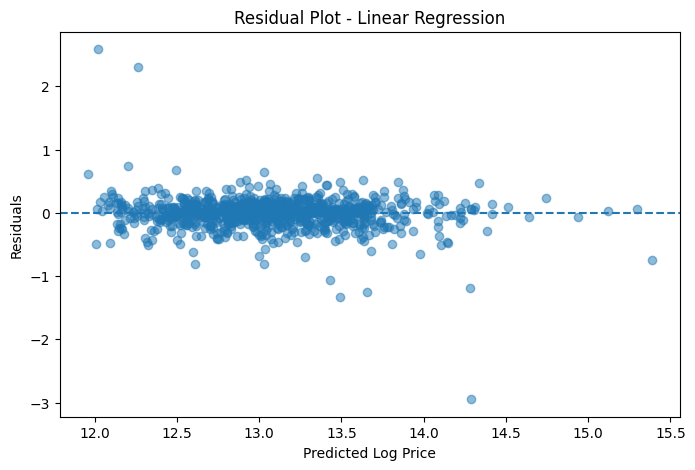

In [36]:
# Step 32: Residual Analysis for Linear Regression

residuals_linear = y_test - y_pred_linear

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_linear, residuals_linear, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

In [38]:
# Step 33: Predict Price for a New House

# Create one sample house using the original feature columns
new_house = X.iloc[[0]].copy()

# Predict log price
predicted_log_price = linear_model.predict(
    scaler.transform(new_house)
    )[0]

    # Convert log price back to original price
predicted_price = np.expm1(predicted_log_price)

print("Predicted House Price: ${:,.2f}".format(predicted_price))

Predicted House Price: $311,501.90


In [39]:
# Step 34: Save Model and Scaler

import joblib

# Save trained model
joblib.dump(linear_model, "house_price_model.pkl")

# Save scaler
joblib.dump(scaler, "house_price_scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [41]:
# Step 35: Verify Saved Model Files

import os

files_to_check = [
    "house_price_model.pkl",
    "house_price_scaler.pkl"
        ]

for file in files_to_check:
            if os.path.exists(file):
                 print(f"✅ {file} — Found")
            else:
                 print(f"❌ {file} — Not Found")

✅ house_price_model.pkl — Found
✅ house_price_scaler.pkl — Found


In [42]:
# Step 36: Load Saved Model and Scaler

import joblib
import numpy as np

# Load saved model and scaler
loaded_model = joblib.load("house_price_model.pkl")
loaded_scaler = joblib.load("house_price_scaler.pkl")

# Use the first test sample
sample = X_test.iloc[[0]]

# Scale the sample
sample_scaled = loaded_scaler.transform(sample)

# Predict log price
sample_log_prediction = loaded_model.predict(sample_scaled)[0]

# Convert back to original price
sample_price_prediction = np.expm1(sample_log_prediction)

print("Saved model loaded successfully!")
print("Test prediction: ${:,.2f}".format(sample_price_prediction))

Saved model loaded successfully!
Test prediction: $1,230,727.17


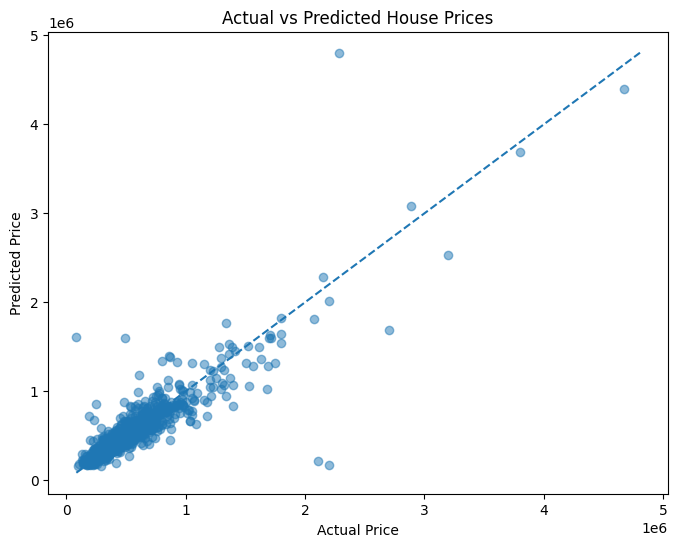

In [43]:
# Step 37: Actual vs Predicted Price

# Convert log values back to original price
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(y_pred_linear)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))

plt.scatter(actual_prices, predicted_prices, alpha=0.5)

# Perfect prediction reference line
min_price = min(actual_prices.min(), predicted_prices.min())
max_price = max(actual_prices.max(), predicted_prices.max())

plt.plot(
    [min_price, max_price],
        [min_price, max_price],
            linestyle="--"
            )

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

Conclusion

In this project, a machine learning regression workflow was developed to predict house prices.

The dataset was first cleaned by removing records with zero prices. Exploratory Data Analysis (EDA) was performed to understand the dataset.

Feature engineering was performed by creating "sale_year", "sale_month", "total_sqft", and "house_age". Categorical features such as "city" and "statezip" were converted into numerical features using One-Hot Encoding. Log transformation was also applied to selected features.

Three regression models were trained and evaluated:

- Linear Regression
- Random Forest Regression
- Gradient Boosting Regression

The models were evaluated using RMSE and MAE.

Model| RMSE| MAE
Linear Regression| 0.257282| 0.154907
Gradient Boosting| 0.285705| 0.195852
Random Forest| 0.287697| 0.187354

Residual analysis and Actual vs Predicted price visualization were performed to analyze model errors.

A sample house price prediction was also demonstrated. Finally, the trained model and scaler were saved using Joblib and successfully loaded again for testing.

This project demonstrates a complete machine learning workflow including data preprocessing, feature engineering, visualization, model training, model evaluation, residual analysis, prediction, and model saving.

In [45]:
# Step 39: Create requirements.txt

requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [47]:
# Step 40: Download requirements.txt

from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# Step 41: Check Project Files

import os

project_files = [
    "house_price_model.pkl",
    "house_price_scaler.pkl",
    "requirements.txt"
            ]

print("===== Project Files =====")

for file in project_files:
    if os.path.exists(file):
          print("✅", file)
    else:
          print("❌", file)

===== Project Files =====
✅ house_price_model.pkl
✅ house_price_scaler.pkl
✅ requirements.txt
